# Packages

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.legend_handler import HandlerTuple
from matplotlib.collections import PatchCollection
from matplotlib.animation import FuncAnimation
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.inspection import permutation_importance
from scipy.stats import norm
import statsmodels.api as sm
import numpy as np
import os
directory = os.getcwd()
parent_directory = os.path.dirname(directory)
%load_ext rpy2.ipython

In [2]:
%%R  -w 8 -h 3 #--units in -r 200
##installing packages and setting options for the plots in R

# {r settings, echo=F, message=F, error=F}
knitr::opts_chunk$set(echo = F)
if (!require("pacman")) install.packages("pacman")
pacman::p_load(ggplot2, patchwork, cowplot, tidyverse, devtools, ggrepel, ggh4x, officer, rvg, svglite, lme4, lmerTest, install = T)

# # Required on the first run, comment afterward?
devtools::install_github("BlakeRMills/MoMAColors")
library(MoMAColors)

theme_set(theme_cowplot() +
          theme(text = element_text(size=9),
                axis.text = element_text(size=9),
                panel.grid.major.x = element_blank() ,
                panel.grid.major.y = element_line( linewidth=.1, color="black")))

Loading required package: pacman
Using GitHub PAT from the git credential store.
Skipping install of 'MoMAColors' from a github remote, the SHA1 (6f5d75de) has not changed since last install.
  Use `force = TRUE` to force installation


# Main 

In [3]:
renderings= ['photo', 'drawing', 'geo', 'word']
items = ['face', 'profil','eyes', 'face2', 'walking', 'standing', 'hand', 'legs', 'bird', 'butterfly', 'girafe', 'fish', 'cherry', 'tree', 'flower', 'carrot', 'watch', 'key', 'truck', 'velo', 'road', 'house', 'mountain', 'windmill']
index_dict ={}
rendering_item = []
count = 0
for rendering in renderings:
  for item in items:
    rendering_item.append(f'{rendering}_{item}')
    count += 1
    index_dict[count] = f'{rendering}_{item}'
    index_dict_reverse = {v: k for k, v in index_dict.items()}


In [4]:
def get_rank(df, rendering_1, rendering_2):
    ranks = []
    rows_rendering_1 = [row for row in df.index if row.startswith(rendering_1)]
    columns_rendering_2 = [col for col in df.columns if col.startswith(rendering_2)]    
    df = df.loc[rows_rendering_1, columns_rendering_2]
    for item in items:
        item_1 = f'{rendering_1}_{item}'
        item_2 = f'{rendering_2}_{item}'
        if item_1 in df.index and item_2 in df.columns:
            distances = df.loc[item_1, :]
            sorted_distances = distances.sort_values()
            rank = sorted_distances.index.get_loc(item_2) + 1
            ranks.append(rank)
    return ranks

In [5]:
base_dir = os.path.join(directory, 'RDMs')
ranks = []
names = []
best_layers = []
count_all = 0
count_last_best = 0
for model in os.listdir(base_dir):
    model_path = os.path.join(base_dir, model)
    best_layer = None
    if os.path.isdir(model_path):  # Ensure it's a folder
        # Find all files that match "layer_n"
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]
        layer_files = [f for f in os.listdir(model_path) if f.startswith("layer_") and f[6:].isdigit()]
        layer_nums = {f: int(f.split("_")[1]) for f in layer_files}
        last_layer = max(layer_nums, key=layer_nums.get)
        layer_files = sorted(layer_files, key=lambda x: int(x.split("_")[1]))
        min_rank = None  # To keep track of the highest rank

        for layer_file in layer_files:
            file_path = os.path.join(model_path, layer_file)
            df = pd.read_csv(file_path, index_col=0)
            
            rank = get_rank(df, 'geo', 'drawing') + get_rank(df, 'geo', 'photo') + get_rank(df, 'drawing', 'photo') + get_rank(df, 'photo', 'drawing') + get_rank(df, 'drawing', 'geo') + get_rank(df, 'photo', 'geo')

            # rank = get_rank(df, 'geo', 'photo') + get_rank(df, 'photo', 'geo')

            mean_rank = np.mean(np.array(rank))

            if min_rank is None or mean_rank <= min_rank:
                min_rank = mean_rank
                best_layer = layer_file
        # Update counts
        count_all += 1
        if best_layer == last_layer:
            count_last_best += 1
        if not best_layer == last_layer:
            print(model)
            print(best_layer)
        best_layers.append(best_layer)
        if min_rank is not None:
            ranks.append(min_rank)
            names.append(model)


convnext_tiny.fb_in22k
layer_2
vit_tiny_in22k
layer_5
convnext_tiny.fb_in1k
layer_2
vit_huge_in22k
layer_32
convnext_large.fb_in22k
layer_1
cornet
layer_2
convnext_small.fb_in1k
layer_1
vit_base_in22k
layer_3
vit_base_patch16_clip_224.laion2b
layer_8
vit_base_patch16_clip_224.openai
layer_8
convnext_base.fb_in22k
layer_1
convnext_base.fb_in1k
layer_1
vit_huge_patch14_clip_224.laion2b
layer_28
vit_small_patch16_224.augreg_in1k
layer_3
vit_giant_patch14_clip_224.laion2b
layer_35
resnet18.a1_in1k
layer_3
resnet50.a1_in1k
layer_3
resnet101.a1_in1k
layer_3
convnext_small.fb_in22k
layer_1
dinov3_7b
layer_34
convnext_large.fb_in1k
layer_1
vit_large_patch14_clip_224.openai
layer_14
vit_base_patch16_224.augreg_in1k
layer_7


In [6]:
count_last_best/count_all

0.46511627906976744

In [7]:
df_ranks = pd.DataFrame({'model': names, 'rank': ranks, 'best_layer':best_layers})
df_ranks = df_ranks.sort_values(by='rank', ascending=True)

In [8]:
df_ranks.to_csv('best_layers.csv')

In [9]:
event_dict = {}
renderings = ["photo","drawing","geo","word"]
items = ['face', 'profil', 'eyes', 'face2', 'walking', 'standing', 'hand', 'legs', 'bird', 'butterfly', 'girafe', 'fish', 'cherry', 'tree', 'flower', 'carrot', 'watch', 'key', 'truck', 'velo', 'road', 'house', 'mountain', 'windmill']
value = 1
for rendering in renderings:
    for item in items:
        event_dict[f"{rendering}_{item}"] = value
        value += 1

In [11]:
metadata = pd.read_csv(parent_directory +'/utils/metadata_models.csv')
metadata_clean = metadata.transpose().reset_index()
metadata_clean.dropna(inplace=True)
metadata_clean.columns = ['model', 'number_parameters', 'train_set']
def clean_number(n):
    num = int(n)//1000000
    return f'{num}M'
dict_sizes = {'in1k' : int(1281167),
              'in22k' :int(14197122),
              'openai-400m' : int(400000000),
              'LVD-142M' : int(142000000),
              'LVD-1689M' : int(1700000000),
              'laion2b': int(2000000000),
              }

# metadata_clean[0] = metadata_clean[0].apply(clean_number)
def classify_backbone(name):
    if 'convnext' in name:
        return "cnn"
    elif name.startswith(("vit", "dino", "clip")):
        return "vit"
    else:
        return "cnn"

metadata_clean["backbone"] = metadata_clean['model'].apply(classify_backbone)

In [14]:
df_plot = pd.merge(metadata_clean, df_ranks, how='outer')
df_plot.columns = ['model', 'number_parameters', 'train_set','backbone', 'rank', 'best_layer']
df_plot['train_set_size'] = df_plot.train_set.apply(lambda x: dict_sizes[x] if pd.notna(x) else None)
df_plot = df_plot.dropna()
df_plot['number_parameters'] = df_plot.number_parameters.apply(lambda x: int(x))
chosen_power = 2/3 

## Compute a function of the number of parameters for the plot, such that the smallest points are visible and the biggests don't take the whole screen
chosen_power = 2/3 

df_plot['power_number_parameters'] = np.power(df_plot['number_parameters'], chosen_power)
df_plot['power_number_parameters'] = np.where(df_plot['number_parameters'] > 5e9, df_plot['power_number_parameters'] / 1.5, df_plot['power_number_parameters'])

# Compute the log of the number of parameters
df_plot['log_number_parameters'] = np.log10(df_plot['number_parameters'])

def adjust_lightness(color, amount=0.5):
    import matplotlib.colors as mc
    import colorsys
    try:
        c = mc.cnames[color]
    except:
        c = color
    c = colorsys.rgb_to_hls(*mc.to_rgb(c))
    return colorsys.hls_to_rgb(c[0], c[1] * amount, c[2])

conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
df_plot.to_csv('all_cors.csv',index=False)

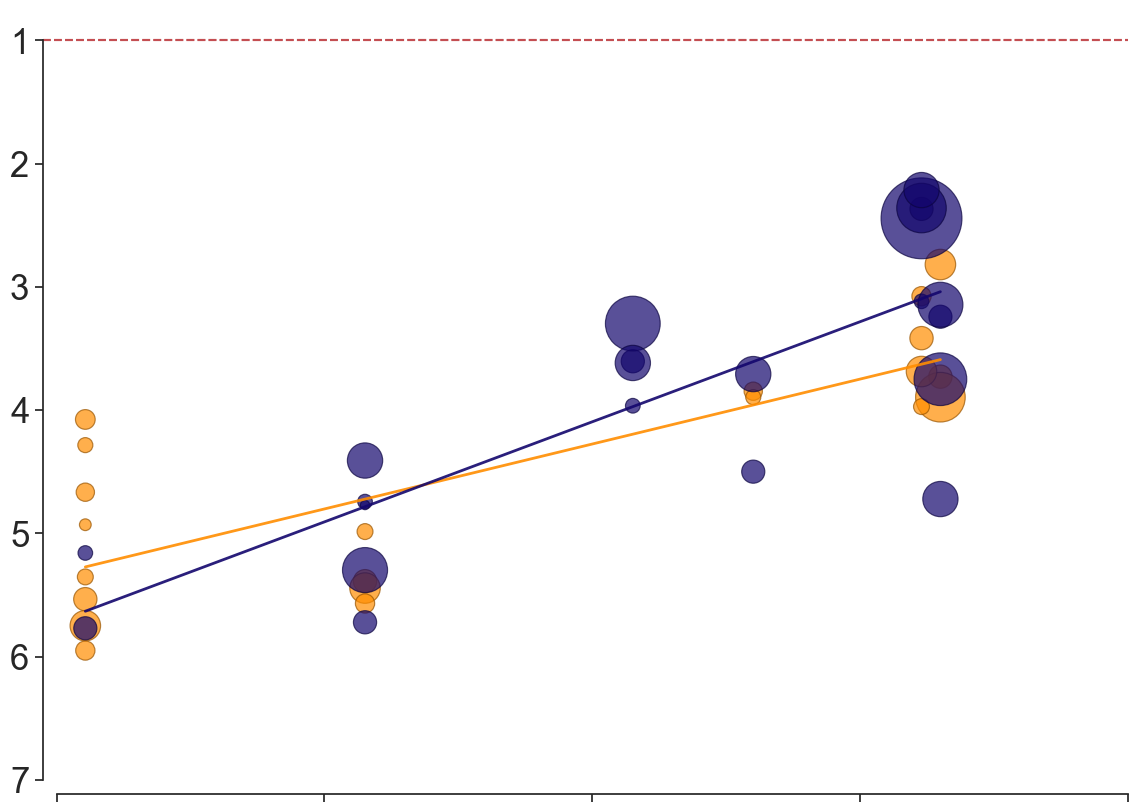

In [16]:
palette = {

    ('cnn'): '#ff8d00',
    ('vit'): '#13066d',  
 
}

human_perf = 1

df_plot['color'] = df_plot.apply(lambda row: palette[(row['backbone'])], axis=1)
df_plot['edge_color']  = [adjust_lightness(color, 0.6) for color in list(df_plot['color'])]

scale_factor = 700
# Plotting with custom colors
sns.set(style='white')
fig, ax = plt.subplots(figsize= (14, 10))
for (train), group_data in df_plot.groupby(['backbone']):
    sns.scatterplot(
        data=group_data,
        x='train_set_size',
        y='rank',
        color=group_data['color'].iloc[0],
        edgecolor=group_data['edge_color'].iloc[0],
        s=group_data['power_number_parameters'] /scale_factor,  # Size proportional to number_parameters
        alpha=0.7,
        legend=False
    )
plt.axhline(y=human_perf, color='r', linestyle='--',)

for backbone, group_data in df_plot.groupby("backbone"):
    # Log-transform X
    X = np.log10(group_data["train_set_size"]).values.reshape(-1, 1)
    y = group_data["rank"].values

    # Fit regression
    reg = LinearRegression().fit(X, y)

    # Make smooth prediction line
    x_range = np.linspace(group_data["train_set_size"].min(),
                          group_data["train_set_size"].max(), 200)
    x_range_log = np.log10(x_range).reshape(-1, 1)
    y_pred = reg.predict(x_range_log)

    # Plot regression line with the same color as the scatter
    ax.plot(
        x_range,
        y_pred,
        color=palette[backbone],
        linewidth=2,
        linestyle="-",
        alpha=0.9,
    )

handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
# size_legend_params = [30_000_000, 150_000_000, 1_000_000_000]  # adjust based on your actual model sizes
# size_legend_dots = [np.power(s, chosen_power)/scale_factor for s in size_legend_params]

# legend_elements = [
#     plt.scatter([], [], s=size, color='gray', alpha=0.5, edgecolors='none',
#                 label=f'{p/1e9:.1f}B params' if p >= 1e9 else f'{int(p/1e6)}M params')
#     for size, p in zip(size_legend_dots, size_legend_params)
# ]
# Place the legend
# ax.legend(
#     handles=legend_elements,
#     title='Model size',
#     loc='lower right',
#     fontsize=14,
#     title_fontsize=16,
#     frameon=False
# )

handles, labels = [],[]
plt.xscale('log')
# Customize labels and ticks
ax.set_yticks([1,2, 3, 4, 5, 6,7])
ax.set_xticks([1e6, 1e7, 1e8, 1e9,1e10])
yticks = ax.get_yticklabels()
xticks = ax.get_xticklabels()

ax.set_ylabel("")
ax.set_xlabel("")
ax.spines['bottom'].set_position(('outward', 10))  

ax.set_yticklabels(yticks, size=25)
ax.set_xticklabels([], size=25)

ax.spines['left'].set_bounds(1, 7)
ax.spines['bottom'].set_bounds(1e6, 1e10)
ax.tick_params(left=True, bottom=True)


ax.invert_yaxis()



plt.axhline(y=human_perf, color='r', linestyle='--',)


sns.despine()
plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/figure_levels_abstraction.svg', format='svg')

In [17]:
features = ['number_parameters', 'train_set_size', 'backbone', 'training_method']
# features = ['number_parameters', 'train_set_size', 'backbone']

target = 'rank'
df_plot = pd.read_csv('all_cors.csv')
conditions = [
    df_plot['model'].str.contains('dino', case=False, na=False),
    df_plot['model'].str.contains('clip', case=False, na=False)
]
choices = ['unsupervised', 'clip']

df_plot['training_method'] = np.select(conditions, choices, default='supervised')
# One-hot encode categorical variables: backbone and training_method
df_features = pd.get_dummies(
    df_plot[features],
    columns=['backbone', 'training_method'],
    # columns=['backbone'],

    drop_first=False
)

# Standardize numerical features
scaler = StandardScaler()
df_features[['number_parameters', 'train_set_size']] = scaler.fit_transform(
    df_features[['number_parameters', 'train_set_size']]
)

X = df_features
y = df_plot[target]

color_significant = '#5A509B'
color_non_significant = '#888'

# Fit Ridge regression
model = Ridge(alpha=1e-2).fit(X, y)
print(model.score(X, y))


0.7604216693985892


In [18]:
def grouped_permutation_importance(model, X, y, groups, n_repeats=30, random_state=0):
    rng = np.random.RandomState(random_state)
    baseline_score = model.score(X, y)

    importances = {}

    for group in groups:
        print(group)
        scores = []
        for _ in range(n_repeats):
            X_permuted = X.copy()
            # permute all columns in this group together
            idx = rng.permutation(len(X))
            X_permuted[group] = X_permuted[group].iloc[idx].values
            scores.append(model.score(X_permuted, y))

        scores = np.array([float(s) for s in scores])
        drops = baseline_score - scores
        mean_drop = np.mean(drops)
        std_drop = np.std(drops)


        m = len(groups)  # number of features
        alpha = 0.05

        # Bonferroni-adjusted z threshold
        z_adj = norm.ppf(1 - alpha / (2*m))
      
        significant = abs(mean_drop) > z_adj * std_drop

        importances[group[0]] = {'mean': mean_drop, 'std': std_drop, 'significant':significant}
       
    return importances



# Example: group dummies for training_method
groups = [
    [col for col in X.columns if col.startswith("training_method_")],
    [col for col in X.columns if col.startswith("backbone_")],
    ['number_parameters'],
    ['train_set_size']
]

importances = grouped_permutation_importance(model, X, y, groups)
feature_importance = pd.DataFrame(importances)
print(feature_importance)
feature_importance2 = feature_importance.T
# Assign colors
feature_importance2['Color'] = feature_importance2['significant'].map(
    {True: color_significant, False: color_non_significant}
)
feature_importance2['Feature'] = feature_importance2.index
feature_importance2.reset_index()

print(feature_importance2)
feature_importance2
feature_importance2.to_csv('temp.csv')

['training_method_clip', 'training_method_supervised', 'training_method_unsupervised']
['backbone_cnn', 'backbone_vit']
['number_parameters']
['train_set_size']
            training_method_clip backbone_cnn number_parameters train_set_size
mean                    0.777079     0.010086          0.015688       0.137414
std                     0.127507     0.011663          0.015763        0.04688
significant                 True        False             False           True
                          mean       std significant    Color  \
training_method_clip  0.777079  0.127507        True  #5A509B   
backbone_cnn          0.010086  0.011663       False     #888   
number_parameters     0.015688  0.015763       False     #888   
train_set_size        0.137414   0.04688        True  #5A509B   

                                   Feature  
training_method_clip  training_method_clip  
backbone_cnn                  backbone_cnn  
number_parameters        number_parameters  
train_set_size   

In addition: Warning messages:
1: `guide_axis_manual()` was deprecated in ggh4x 0.3.0.
ℹ Please use `legendry::guide_axis_base()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
2: The S3 guide system was deprecated in ggplot2 3.5.0.
ℹ It has been replaced by a ggproto system that can be extended.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 
3: `is.ggproto()` was deprecated in ggplot2 3.5.2.
ℹ Please use `is_ggproto()` instead.
This warning is displayed once every 8 hours.
Call `lifecycle::last_lifecycle_warnings()` to see where this warning was
generated. 


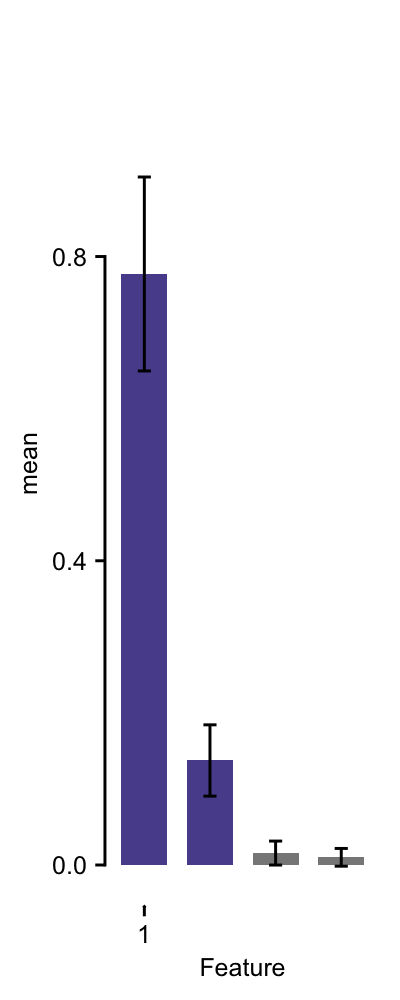

In [19]:
%%R -w 2 -h 5  --units in -r 200

feature_importance <- read.csv('temp.csv')
feature_importance <- feature_importance %>%
  arrange(desc(mean))

feature_importance$Feature <- factor(feature_importance$Feature, levels = feature_importance$Feature)

# Create the ggplot2 bar plot
p <- ggplot(feature_importance, aes(x = Feature, y = mean, fill = Color)) +
    geom_col(width = 0.7) + # geom_col for pre-computed heights, width adjusts bar thickness
    geom_errorbar(
      aes(ymin = mean - std, ymax = mean + std),
      width = 0.2, # Adjust the width of the error bar caps
      color = "black" # Color of the error bars
    ) +
    # geom_text(
    #   aes(y = mean ,label = round(mean, 2)), # Add numeric value above each bar, rounded to 2 decimal places
    #   vjust = -0.5, # Adjust vertical position of the text
    #   hjust = -0.2,
    #   color = "black", # Color of the text
    #   size = 3 # Size of the text
    # ) +
    scale_fill_identity() + # Use the 'Color' column directly for fill
    # Customizing the theme for a "prettier" look and removing top/right spines
    # theme_minimal() + # Start with a minimal theme
    theme(
      panel.grid.major = element_blank(), # Remove major grid lines
      panel.grid.minor = element_blank(), # Remove minor grid lines
      panel.background = element_blank(), 
      panel.grid.major.y = element_blank(),

    ) +
    # Set y-axis limits and breaks similar to your Python code
    # The Python y-axis was inverted, but for means, a standard positive up is usually preferred.
    # If you truly want to invert, you'd use scale_y_reverse().
  

    guides(x = guide_axis_manual(trunc_lower=1, trunc_upper=1, breaks=c(1)),
          y = guide_axis_manual(trunc_lower=0, trunc_upper=0.8, breaks=seq(0,0.8,0.4))) +


    coord_cartesian(ylim = c(min(feature_importance$mean - feature_importance$std) * 1.1,
                            max(feature_importance$mean + feature_importance$std) * 1.1 + max(feature_importance$std) * 0.5)
                    )  # This helps control the visible range without dropping data
  
ggsave("plots/feature_importance.svg", p, device='svg',width = 2, height = 5, units = "in")
p

In [6]:
%%R -w 2 -h 4  --units in -r 200

df <- read.csv("all_cors.csv")
df <- na.omit(df[, c("rank","train_set_size","number_parameters","backbone","training_method")])

df$log_train_set_size <- log(df$train_set_size)
df$log_number_parameters <- log(df$number_parameters)

# Random intercepts 
m1 <- lmer(rank ~ log_train_set_size + log_number_parameters +
             (1|training_method) + (1|backbone),
           data=df, REML=TRUE)
print(summary(m1))

# Random intercepts and random slopes for dataset size by training_method and backbone
m2 <- lmer(rank ~ log_train_set_size + log_number_parameters +
             (1 + log_train_set_size|training_method) + (1 |backbone),
           data=df, REML=TRUE)

# Compare models with max likelihood
m1_ml <- update(m1, REML=FALSE)
m2_ml <- update(m2, REML=FALSE)
anova(m1_ml, m2_ml)

Linear mixed model fit by REML. t-tests use Satterthwaite's method [
lmerModLmerTest]
Formula: 
rank ~ log_train_set_size + log_number_parameters + (1 | training_method) +  
    (1 | backbone)
   Data: df

REML criterion at convergence: 86.2

Scaled residuals: 
     Min       1Q   Median       3Q      Max 
-2.15834 -0.76194  0.04334  0.83223  1.91081 

Random effects:
 Groups          Name        Variance Std.Dev.
 training_method (Intercept) 0.3335   0.5775  
 backbone        (Intercept) 0.0000   0.0000  
 Residual                    0.3246   0.5698  
Number of obs: 43, groups:  training_method, 3; backbone, 2

Fixed effects:
                      Estimate Std. Error       df t value Pr(>|t|)    
(Intercept)            7.70410    1.64737 22.24612   4.677 0.000113 ***
log_train_set_size    -0.15950    0.07002 16.85309  -2.278 0.036067 *  
log_number_parameters -0.03629    0.06721 37.83338  -0.540 0.592412    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Correlati

boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')
boundary (singular) fit: see help('isSingular')


# Make theoretical RDM

In [20]:
theoretical_rdm = np.zeros((96,96))
for i in range(96):
    for j in range(96):
        rendering_diff = abs(i//24 - j//24)/4
        category_diff = (int(((i%24)//6)!=((j%24)//6))/4)/2.8355
        object_diff = int(((i%24))!=((j%24)))
        theoretical_rdm[i,j] = rendering_diff + object_diff + category_diff

theoretical_rdm_df = pd.DataFrame(theoretical_rdm) 

theoretical_rdm_df.to_csv('RDMs/theoretical')

# Layerwise analysis

In [21]:
ranks = []
base_dir = os.path.join(directory, 'RDMs/dinov3_large')

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [(pd.read_csv(f, index_col=0)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers

model_rdms = model_rdms[:-1]
layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    rank = get_rank(model_rdm, 'geo', 'drawing') + get_rank(model_rdm, 'geo', 'photo') + get_rank(model_rdm, 'drawing', 'photo') + get_rank(model_rdm, 'photo', 'drawing') + get_rank(model_rdm, 'drawing', 'geo') + get_rank(model_rdm, 'photo', 'geo')
    mean_rank = np.mean(np.array(rank))
    ranks.append(mean_rank)




# Create DataFrame for original correlations
df_original = pd.DataFrame({'layer': layers, 'rank': ranks})

In [22]:
ranks = []
base_dir = os.path.join(directory, 'RDMs/vit_giant_patch14_clip_224.laion2b')

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [(pd.read_csv(f, index_col=0)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers

model_rdms = model_rdms[:-1]
layers = layers[:-1]
layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    rank = get_rank(model_rdm, 'geo', 'drawing') + get_rank(model_rdm, 'geo', 'photo') + get_rank(model_rdm, 'drawing', 'photo') + get_rank(model_rdm, 'photo', 'drawing') + get_rank(model_rdm, 'drawing', 'geo') + get_rank(model_rdm, 'photo', 'geo')
    mean_rank = np.mean(np.array(rank))
    ranks.append(mean_rank)




# Create DataFrame for original correlations
df_2 = pd.DataFrame({'layer': layers, 'rank': ranks})

In [23]:
ranks = []
base_dir = os.path.join(directory, 'RDMs/convnext_xxlarge.clip_laion2b_soup')

# Store paths to layer files to process them once
layer_file_paths = []
if os.path.isdir(base_dir):
    layer_files = [f for f in os.listdir(base_dir) if f.startswith("layer_") and f[6:].isdigit()]
    for layer_file in sorted(layer_files, key=lambda x: int(x[6:])):
        layer_file_paths.append(os.path.join(base_dir, layer_file))

# Load all layer RDMs once to avoid re-reading in the loop
model_rdms = [(pd.read_csv(f, index_col=0)) for f in layer_file_paths]
layers = [int(os.path.basename(f)[6:]) for f in layer_file_paths] # Get layer numbers


layers = [(i)/(len(layers)-1) for i in layers]
# Calculate original correlations
for model_rdm in model_rdms:
    rank = get_rank(model_rdm, 'geo', 'drawing') + get_rank(model_rdm, 'geo', 'photo') + get_rank(model_rdm, 'drawing', 'photo') + get_rank(model_rdm, 'photo', 'drawing') + get_rank(model_rdm, 'drawing', 'geo') + get_rank(model_rdm, 'photo', 'geo')
    mean_rank = np.mean(np.array(rank))
    ranks.append(mean_rank)




# Create DataFrame for original correlations
df_3 = pd.DataFrame({'layer': layers, 'rank': ranks})

/var/folders/yr/1hvrtjdn3hzc_7rf_6kpdl69v063g3/T/ipykernel_22694/1817910794.py:38: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend().remove()


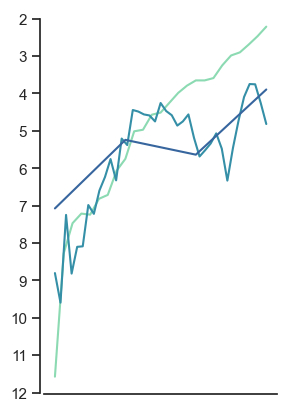

In [24]:
fig, ax = plt.subplots(figsize=(3, 5))
palette = sns.color_palette("mako_r", as_cmap=False)

models = ['dinov3_large', 'vit_clip_giant_laion2b', 'convnext_xxlarge_clip_laion2b']

# sns.lineplot(data=df_original, y='rank', x='layer', hue='layer', dodge=False,
#             palette=palette, hue_norm=(df_original['layer'].min(), df_original['layer'].max()))

sns.lineplot(data=df_original, y='rank', x='layer', color=palette[0])

sns.lineplot(data=df_2, y='rank', x='layer', color=palette[2])

sns.lineplot(data=df_3, y='rank', x='layer', color=palette[3])

# sns.lineplot(data=df_4, y='rank', x='layer', color=palette[4])

ax.set_yticks(range(2,13))
# ax.set_xticks([i for i in range(13)])


yticks = ax.get_yticklabels()
# xticks = ax.get_xticklabels()


ax.set_ylabel("")
# ax.set_xlabel("")

ax.set_yticklabels(yticks, size=12)
ax.spines['left'].set_bounds(2, 12)
ax.tick_params(left=True, bottom=False)

# ax.spines['bottom'].set_position(('outward', 5))  # shift outward by 10 points
ax.get_xaxis().set_visible(False)   

ax.invert_yaxis()
ax.spines['left'].set_position(('outward', 3))  

plt.legend().remove()
sns.despine()
# plt.rcParams['svg.fonttype'] = 'none'
fig.savefig('plots/corr_layers.svg', format='svg')

# Displaying some example images

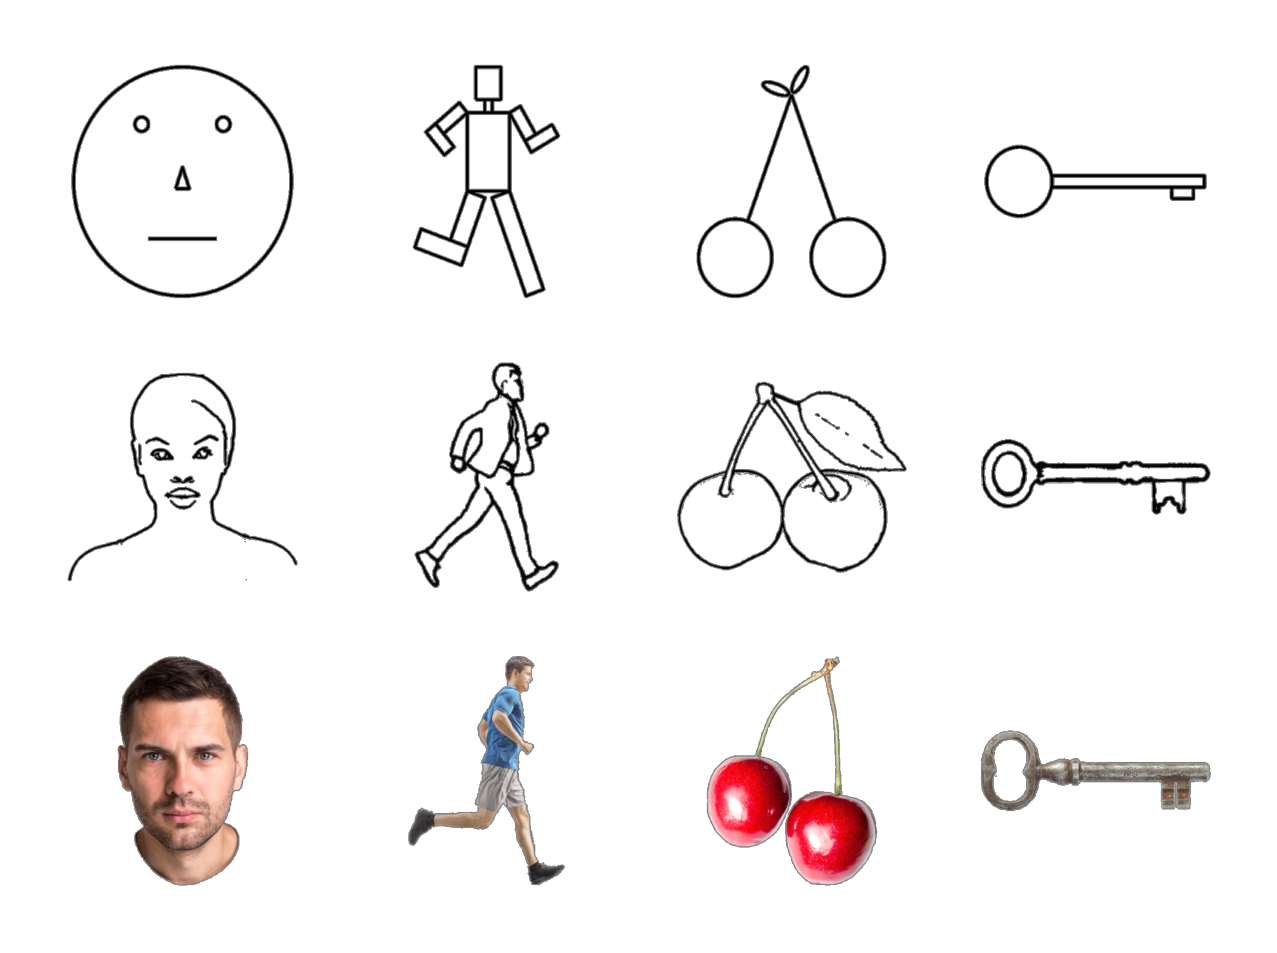

In [25]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os

# Path to your images
img_dir = "images_backgroundless"

# Select 4 items (indices 0..23 for photos, 24..47 for drawings, -24..-1 for geometries)
items = [1, 5, 13, 18]  # example item indices (photo indices)

# Create figure
fig, axes = plt.subplots(3, 4, figsize=(10, 6))  # 3 rows, 4 columns

for col, item in enumerate(items):
    # Determine indices for each format
    photo_idx = item
    drawing_idx = item + 24
    geometry_idx = item + 48  # assuming negative indices wrap to geometry

    # List of indices in row order
    # indices = [photo_idx, drawing_idx, geometry_idx]
    indices = [geometry_idx, drawing_idx, photo_idx]
    for row, idx in enumerate(indices):
        img_path = os.path.join(img_dir, f"{idx}.png")  # adjust extension if needed
        img = mpimg.imread(img_path)
        axes[row, col].imshow(img)
        axes[row, col].axis("off")

# Optional: add row/column labels
# row_labels = ["Photo", "Drawing", "Geometry"]
row_labels = ["Geometry", "Drawing", "Photo"]

for ax, label in zip(axes[:,0], row_labels):
    ax.set_ylabel(label, fontsize=14)

plt.tight_layout(pad=-10, w_pad=-5, h_pad=-3)  # reduce whitespace between images
plt.show()